In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
df = pd.read_csv( 'data/Car_Insurance_Claim.csv')
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [4]:
print(df.shape)
df.info()

(10000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  str    
 2   GENDER               10000 non-null  str    
 3   RACE                 10000 non-null  str    
 4   DRIVING_EXPERIENCE   10000 non-null  str    
 5   EDUCATION            10000 non-null  str    
 6   INCOME               10000 non-null  str    
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  str    
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  str    
 15  SPEEDING_VIOLATIONS  10000 non-null 

In [5]:
df.isnull().sum()

ID                       0
AGE                      0
GENDER                   0
RACE                     0
DRIVING_EXPERIENCE       0
EDUCATION                0
INCOME                   0
CREDIT_SCORE           982
VEHICLE_OWNERSHIP        0
VEHICLE_YEAR             0
MARRIED                  0
CHILDREN                 0
POSTAL_CODE              0
ANNUAL_MILEAGE         957
VEHICLE_TYPE             0
SPEEDING_VIOLATIONS      0
DUIS                     0
PAST_ACCIDENTS           0
OUTCOME                  0
dtype: int64

In [6]:
df['OUTCOME'].value_counts()

OUTCOME
0.0    6867
1.0    3133
Name: count, dtype: int64

In [7]:
categorical_cols = ['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']

for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print()

AGE
AGE
26-39    3063
40-64    2931
16-25    2016
65+      1990
Name: count, dtype: int64

GENDER
GENDER
female    5010
male      4990
Name: count, dtype: int64

RACE
RACE
majority    9012
minority     988
Name: count, dtype: int64

DRIVING_EXPERIENCE
DRIVING_EXPERIENCE
0-9y      3530
10-19y    3299
20-29y    2119
30y+      1052
Name: count, dtype: int64

EDUCATION
EDUCATION
high school    4157
university     3928
none           1915
Name: count, dtype: int64

INCOME
INCOME
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64

VEHICLE_YEAR
VEHICLE_YEAR
before 2015    6967
after 2015     3033
Name: count, dtype: int64

VEHICLE_TYPE
VEHICLE_TYPE
sedan         9523
sports car     477
Name: count, dtype: int64



In [8]:
print(df['CREDIT_SCORE'].describe())
print()
print(df['ANNUAL_MILEAGE'].describe())

count    9018.000000
mean        0.515813
std         0.137688
min         0.053358
25%         0.417191
50%         0.525033
75%         0.618312
max         0.960819
Name: CREDIT_SCORE, dtype: float64

count     9043.000000
mean     11697.003207
std       2818.434528
min       2000.000000
25%      10000.000000
50%      12000.000000
75%      14000.000000
max      22000.000000
Name: ANNUAL_MILEAGE, dtype: float64


In [9]:
df['CREDIT_SCORE'] = df['CREDIT_SCORE'].fillna(df['CREDIT_SCORE'].mean())
df['ANNUAL_MILEAGE'] = df['ANNUAL_MILEAGE'].fillna(df['ANNUAL_MILEAGE'].mean())

In [10]:
df.isnull().sum()

ID                     0
AGE                    0
GENDER                 0
RACE                   0
DRIVING_EXPERIENCE     0
EDUCATION              0
INCOME                 0
CREDIT_SCORE           0
VEHICLE_OWNERSHIP      0
VEHICLE_YEAR           0
MARRIED                0
CHILDREN               0
POSTAL_CODE            0
ANNUAL_MILEAGE         0
VEHICLE_TYPE           0
SPEEDING_VIOLATIONS    0
DUIS                   0
PAST_ACCIDENTS         0
OUTCOME                0
dtype: int64

In [11]:
age_map = {'16-25' : 0, '26-39' : 1, '40-64' : 2, '65+' : 3}
experience_map = {'0-9y' : 0, '10-19y' : 1, '20-29y' : 2, '30y+' : 3}
education_map = {'none' : 0, 'high school' : 1, 'university' : 2}
income_map = {'poverty' : 0, 'working class' : 1, 'middle class' : 2, 'upper class' : 3}

df['AGE'] = df['AGE'].map(age_map)
df['DRIVING_EXPERIENCE'] = df['DRIVING_EXPERIENCE'].map(experience_map)
df['EDUCATION'] = df['EDUCATION'].map(education_map)
df['INCOME'] = df['INCOME'].map(income_map)

In [12]:
df[['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']].head()
print(df[['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']].isnull().sum())

AGE                   0
DRIVING_EXPERIENCE    0
EDUCATION             0
INCOME                0
dtype: int64


In [13]:
df = pd.get_dummies(df, columns=['GENDER', 'RACE', 'VEHICLE_TYPE'], drop_first=True)
df.head()

,ID,AGE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,GENDER_male,RACE_minority,VEHICLE_TYPE_sports car
0,569520,3,0,1,3,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,0,0,0,0.0,False,False,False
1,750365,0,0,0,0,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,0,0,0,1.0,True,False,False
2,199901,0,0,1,1,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,0,0,0,0.0,False,False,False
3,478866,0,0,2,1,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,0,0,0,0.0,True,False,False
4,731664,1,1,0,1,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,2,0,1,1.0,True,False,False


In [14]:
df['VEHICLE_YEAR'] = df['VEHICLE_YEAR'].map({'before 2015': 0, 'after 2015': 1})
print(df['VEHICLE_YEAR'].value_counts())

VEHICLE_YEAR
0    6967
1    3033
Name: count, dtype: int64


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   AGE                      10000 non-null  int64  
 2   DRIVING_EXPERIENCE       10000 non-null  int64  
 3   EDUCATION                10000 non-null  int64  
 4   INCOME                   10000 non-null  int64  
 5   CREDIT_SCORE             10000 non-null  float64
 6   VEHICLE_OWNERSHIP        10000 non-null  float64
 7   VEHICLE_YEAR             10000 non-null  int64  
 8   MARRIED                  10000 non-null  float64
 9   CHILDREN                 10000 non-null  float64
 10  POSTAL_CODE              10000 non-null  int64  
 11  ANNUAL_MILEAGE           10000 non-null  float64
 12  SPEEDING_VIOLATIONS      10000 non-null  int64  
 13  DUIS                     10000 non-null  int64  
 14  PAST_ACCIDENTS           10000 non

In [16]:
df = df.drop(columns=['ID', 'RACE_minority', 'GENDER_male', 'POSTAL_CODE'])
print(df.columns.tolist())

['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR', 'MARRIED', 'CHILDREN', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'OUTCOME', 'VEHICLE_TYPE_sports car']


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(8000, 14) (2000, 14)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print(model)

LogisticRegression(max_iter=1000)


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86      1373
         1.0       0.69      0.72      0.71       627

    accuracy                           0.81      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.81      0.81      0.81      2000

AUC: 0.876031368230548


In [20]:
import pandas as pd 

coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(coefficients)

                    feature  coefficient
10      SPEEDING_VIOLATIONS     0.327766
9            ANNUAL_MILEAGE     0.136420
11                     DUIS     0.097217
2                 EDUCATION     0.035045
3                    INCOME     0.029870
0                       AGE     0.000678
13  VEHICLE_TYPE_sports car    -0.014930
4              CREDIT_SCORE    -0.106771
8                  CHILDREN    -0.111355
7                   MARRIED    -0.181578
12           PAST_ACCIDENTS    -0.196042
5         VEHICLE_OWNERSHIP    -0.749100
6              VEHICLE_YEAR    -0.759095
1        DRIVING_EXPERIENCE    -1.829350


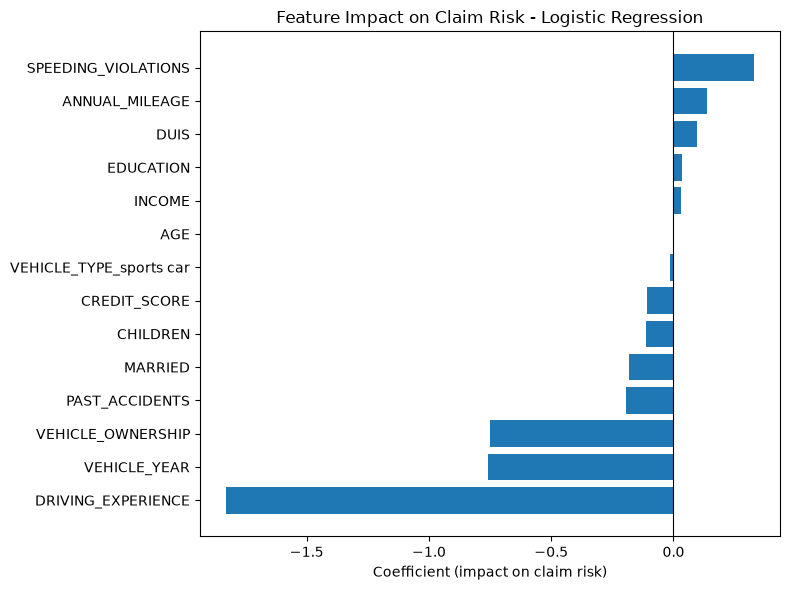

In [21]:
import matplotlib.pyplot as plt

coefficients_sorted = coefficients.sort_values(by='coefficient')

plt.figure(figsize=(8, 6))
plt.barh(coefficients_sorted['feature'], coefficients_sorted['coefficient'])
plt.xlabel('Coefficient (impact on claim risk)')
plt.title('Feature Impact on Claim Risk - Logistic Regression')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
print(rf_model)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_pred_proba_rf))

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)
              precision    recall  f1-score   support

         0.0       0.86      0.87      0.87      1373
         1.0       0.71      0.70      0.70       627

    accuracy                           0.81      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.81      0.81      0.81      2000

AUC: 0.869170293807086


In [23]:
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(rf_importance)

                    feature  importance
1        DRIVING_EXPERIENCE    0.260747
0                       AGE    0.140922
5         VEHICLE_OWNERSHIP    0.136151
6              VEHICLE_YEAR    0.091704
10      SPEEDING_VIOLATIONS    0.076690
4              CREDIT_SCORE    0.070498
3                    INCOME    0.066393
12           PAST_ACCIDENTS    0.061943
9            ANNUAL_MILEAGE    0.034367
7                   MARRIED    0.019759
8                  CHILDREN    0.015625
2                 EDUCATION    0.011476
11                     DUIS    0.008859
13  VEHICLE_TYPE_sports car    0.004866
